# Model 1: Basic Seq2Seq (LSTM, no attention)

**Prerequisites:** run `01_preprocessing.ipynb` first to generate the processed data files.

**Environments:** runs locally and in Google Colab. In Colab, use a GPU runtime (Runtime > Change runtime type > T4 GPU) and run `01_preprocessing.ipynb` in the same session beforehand.

In [ ]:
import json
import sys
from pathlib import Path

import pandas as pd
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    PROCESSED_DIR = Path("processed_full")
    CHECKPOINT_PATH = Path("best_basic_full.pt")
else:
    PROCESSED_DIR = Path("../../data/processed_full")
    CHECKPOINT_PATH = Path("../../results/best_basic_full.pt")

CHECKPOINT_PATH.parent.mkdir(exist_ok=True)

PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3
BATCH_SIZE = 32

with open(PROCESSED_DIR / "token2idx.json") as f:
    tokenToIdx = json.load(f)
idxToToken = {v: k for k, v in tokenToIdx.items()}


def encode(tokens: list[str]) -> list[int]:
    """
    Converts a list of string tokens to an integer ID sequence with SOS/EOS.
    @param tokens: List of string tokens to encode.
    @return: List of integer token IDs with SOS at index 0 and EOS at the end.
    """
    return [SOS_IDX] + [tokenToIdx.get(t, UNK_IDX) for t in tokens] + [EOS_IDX]


def decode(ids: list[int]) -> list[str]:
    """
    Converts integer token IDs back to string tokens, skipping special tokens.
    @param ids: List of integer token IDs.
    @return: List of string tokens with PAD, SOS, and EOS removed.
    """
    return [idxToToken[i] for i in ids if i not in {PAD_IDX, SOS_IDX, EOS_IDX}]


with open(PROCESSED_DIR / "train.json") as f:
    trainDf = pd.DataFrame(json.load(f))
with open(PROCESSED_DIR / "dev.json") as f:
    devDf = pd.DataFrame(json.load(f))
with open(PROCESSED_DIR / "test.json") as f:
    testDf = pd.DataFrame(json.load(f))

print(f"Vocabulary size : {len(tokenToIdx):,}")
print(
    f"Q&A pairs -- train: {len(trainDf):,}  dev: {len(devDf):,}  test: {len(testDf):,}"
)


class WikiQADataset(Dataset):
    """
    PyTorch Dataset wrapping the pre-encoded WikiQA question-answer pairs.
    @param dataFrame: DataFrame with 'q_ids' and 'a_ids' columns of integer ID lists.
    """

    def __init__(self, dataFrame: pd.DataFrame):
        self.qIds = dataFrame["q_ids"].tolist()
        self.aIds = dataFrame["a_ids"].tolist()

    def __len__(self) -> int:
        return len(self.qIds)

    def __getitem__(self, idx: int):
        return torch.tensor(self.qIds[idx]), torch.tensor(self.aIds[idx])


def collateBatch(batch: list) -> dict:
    """
    Pads a list of (question, answer) tensor pairs into fixed-length batch tensors.
    @param batch: List of (question tensor, answer tensor) pairs from WikiQADataset.
    @return: Dict with keys 'src', 'tgt', and 'srcLens' as batch tensors.
    """
    questions, answers = zip(*batch)
    src = pad_sequence(questions, batch_first=True, padding_value=PAD_IDX)
    tgt = pad_sequence(answers, batch_first=True, padding_value=PAD_IDX)
    return {
        "src": src,
        "tgt": tgt,
        "srcLens": torch.tensor([len(q) for q in questions]),
    }


trainLoader = DataLoader(
    WikiQADataset(trainDf), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collateBatch
)
devLoader = DataLoader(
    WikiQADataset(devDf), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collateBatch
)
testLoader = DataLoader(
    WikiQADataset(testDf), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collateBatch
)

print(
    f"Batches -- train: {len(trainLoader)}  dev: {len(devLoader)}  test: {len(testLoader)}"
)

Vocabulary size : 17,956
Q&A pairs -- train: 16,206  dev: 2,194  test: 4,934
Batches -- train: 507  dev: 69  test: 155


---

## Part 2: Model architecture

A standard LSTM encoder-decoder with no attention.

The encoder reads the full question and compresses it into a hidden state `(h_n, c_n)`. The decoder is stepped one token at a time, initialised with that hidden state. During training, teacher forcing randomly replaces the decoder's own previous prediction with the ground-truth token.

In [2]:
import torch.nn as nn

# ── Hyperparameters ────────────────────────────────────────────────────────────
EMBED_DIM = 256
HIDDEN_DIM = 256
N_LAYERS = 1
DROPOUT = 0.5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
import torch.nn as nn


class Encoder(nn.Module):
    """
    LSTM encoder that compresses an input token sequence into a hidden state.
    @param vocabSize: Number of tokens in the vocabulary.
    @param embedDim: Dimensionality of the token embedding vectors.
    @param hiddenDim: Number of hidden units in the LSTM.
    @param nLayers: Number of stacked LSTM layers.
    @param dropout: Dropout probability applied to embeddings and between LSTM layers.
    """

    def __init__(
        self,
        vocabSize: int,
        embedDim: int,
        hiddenDim: int,
        nLayers: int,
        dropout: float,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedDim,
            hiddenDim,
            nLayers,
            batch_first=True,
            dropout=dropout if nLayers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src: torch.Tensor, srcLens: torch.Tensor):
        embedded = self.dropout(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, srcLens.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.lstm(packed)
        return hidden


class Decoder(nn.Module):
    """
    LSTM decoder that generates one output token per step given a hidden state.
    @param vocabSize: Number of tokens in the vocabulary.
    @param embedDim: Dimensionality of the token embedding vectors.
    @param hiddenDim: Number of hidden units in the LSTM.
    @param nLayers: Number of stacked LSTM layers.
    @param dropout: Dropout probability applied to embeddings.
    """

    def __init__(
        self,
        vocabSize: int,
        embedDim: int,
        hiddenDim: int,
        nLayers: int,
        dropout: float,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedDim,
            hiddenDim,
            nLayers,
            batch_first=True,
            dropout=dropout if nLayers > 1 else 0.0,
        )
        self.fc = nn.Linear(hiddenDim, vocabSize)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token: torch.Tensor, hidden):
        embedded = self.dropout(self.embedding(token.unsqueeze(1)))
        output, hidden = self.lstm(embedded, hidden)
        logits = self.fc(output.squeeze(1))
        return logits, hidden


class Seq2Seq(nn.Module):
    """
    Full encoder-decoder sequence-to-sequence model combining Encoder and Decoder.
    @param encoder: Encoder instance that produces hidden states from source sequences.
    @param decoder: Decoder instance that generates tokens step-by-step.
    """

    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        src: torch.Tensor,
        srcLens: torch.Tensor,
        tgt: torch.Tensor,
        teacherForcingRatio: float = 0.5,
    ):
        batchSize, tgtLen = tgt.shape
        vocabSize = self.decoder.fc.out_features

        hidden = self.encoder(src, srcLens)

        outputs = torch.zeros(batchSize, tgtLen, vocabSize, device=src.device)
        token = tgt[:, 0]  # <sos>

        for t in range(1, tgtLen):
            logits, hidden = self.decoder(token, hidden)
            outputs[:, t] = logits
            useTeacher = torch.rand(1).item() < teacherForcingRatio
            token = tgt[:, t] if useTeacher else logits.argmax(dim=-1)

        return outputs

In [4]:
encoder = Encoder(len(tokenToIdx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(len(tokenToIdx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model = Seq2Seq(encoder, decoder).to(DEVICE)

nParams = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {nParams:,}")

# Smoke test -- one forward pass
batch = next(iter(trainLoader))
out = model(batch["src"].to(DEVICE), batch["srcLens"], batch["tgt"].to(DEVICE))
print(
    f"Output shape: {out.shape}  (expected [batch={BATCH_SIZE}, tgt_len, vocab={len(tokenToIdx)}])"
)

Trainable parameters: 14,860,836
Output shape: torch.Size([32, 31, 17956])  (expected [batch=32, tgt_len, vocab=17956])


---

## Part 3: Training

- **Loss:** cross-entropy, `<pad>` positions ignored
- **Optimiser:** Adam
- **Gradient clipping:** norm clipped to 1.0 to prevent exploding gradients (common with LSTMs)
- **Checkpoint:** best model by validation loss is saved to `CHECKPOINT_PATH`

In [5]:
import math
import time
import matplotlib.pyplot as plt

EPOCHS = 30
LEARNING_RATE = 5e-4
CLIP = 1.0
TEACHER_FORCING = 0.7
PATIENCE = 3

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def trainEpoch(
    model: Seq2Seq,
    loader: DataLoader,
    optimizer,
    criterion,
    clip: float,
) -> float:
    """
    Runs one full training pass over the provided data loader.
    @param model: The Seq2Seq model to train.
    @param loader: DataLoader yielding batches with 'src', 'tgt', and 'srcLens' keys.
    @param optimizer: Optimizer instance for parameter updates.
    @param criterion: Loss function (CrossEntropyLoss with PAD ignored).
    @param clip: Maximum gradient norm for gradient clipping.
    @return: Mean cross-entropy loss over all batches.
    """
    model.train()
    totalLoss = 0.0
    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        srcLens = batch["srcLens"]

        optimizer.zero_grad()
        output = model(src, srcLens, tgt, TEACHER_FORCING)

        loss = criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        totalLoss += loss.item()
    return totalLoss / len(loader)


@torch.no_grad()
def evaluate(model: Seq2Seq, loader: DataLoader, criterion) -> float:
    """
    Evaluates the model on a data loader without updating parameters.
    @param model: The Seq2Seq model to evaluate.
    @param loader: DataLoader yielding batches with 'src', 'tgt', and 'srcLens' keys.
    @param criterion: Loss function (CrossEntropyLoss with PAD ignored).
    @return: Mean cross-entropy loss over all batches.
    """
    model.eval()
    totalLoss = 0.0
    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        srcLens = batch["srcLens"]
        output = model(src, srcLens, tgt, teacherForcingRatio=0.0)
        totalLoss += criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        ).item()
    return totalLoss / len(loader)

In [6]:
trainLosses, valLosses = [], []
bestValLoss = float("inf")
epochsNoImprove = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    trainLoss = trainEpoch(model, trainLoader, optimizer, criterion, CLIP)
    valLoss = evaluate(model, devLoader, criterion)
    elapsed = time.time() - t0

    trainLosses.append(trainLoss)
    valLosses.append(valLoss)

    marker = ""
    if valLoss < bestValLoss:
        bestValLoss = valLoss
        epochsNoImprove = 0
        torch.save(
            {
                "model_state": model.state_dict(),
                "tokenToIdx": tokenToIdx,
                "embed_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM,
                "n_layers": N_LAYERS,
                "dropout": DROPOUT,
            },
            CHECKPOINT_PATH,
        )
        marker = "  ✓ saved"
    else:
        epochsNoImprove += 1
        if epochsNoImprove >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch}  (no improvement for {PATIENCE} epochs)"
            )
            break

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {trainLoss:.4f} (ppl {math.exp(trainLoss):6.2f}) | "
        f"val loss {valLoss:.4f} (ppl {math.exp(valLoss):6.2f}) | "
        f"{elapsed:.1f}s{marker}"
    )

print(f"\nBest val loss: {bestValLoss:.4f}")

Epoch 01/30 | train loss 7.1314 (ppl 1250.63) | val loss 7.0650 (ppl 1170.26) | 39.7s  ✓ saved
Epoch 02/30 | train loss 6.7144 (ppl 824.16) | val loss 7.0957 (ppl 1206.79) | 38.1s
Epoch 03/30 | train loss 6.5643 (ppl 709.33) | val loss 7.1248 (ppl 1242.34) | 38.1s
Early stopping at epoch 4  (no improvement for 3 epochs)

Best val loss: 7.0650


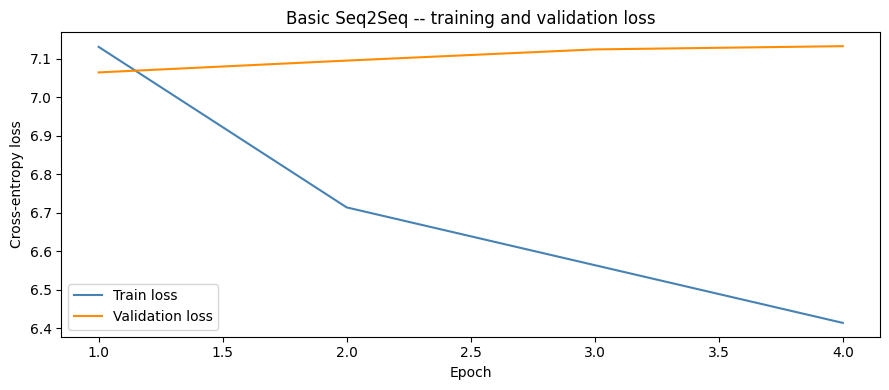

In [7]:
epochsRange = range(1, len(trainLosses) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochsRange, trainLosses, label="Train loss", color="steelblue")
plt.plot(epochsRange, valLosses, label="Validation loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Basic Seq2Seq -- training and validation loss")
plt.legend()
plt.tight_layout()
plt.savefig(CHECKPOINT_PATH.parent / "basic_loss_curves.png", dpi=150)
plt.show()

---

## Part 5: Inference

Load the best checkpoint and generate answers greedily (no teacher forcing).

In [8]:
import re
import nltk

nltk.download("punkt_tab", quiet=True)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

ckptTokenToIdx = checkpoint["tokenToIdx"]
ckptEncoder = Encoder(
    len(ckptTokenToIdx),
    checkpoint["embed_dim"],
    checkpoint["hidden_dim"],
    checkpoint["n_layers"],
    checkpoint["dropout"],
)
ckptDecoder = Decoder(
    len(ckptTokenToIdx),
    checkpoint["embed_dim"],
    checkpoint["hidden_dim"],
    checkpoint["n_layers"],
    checkpoint["dropout"],
)
bestModel = Seq2Seq(ckptEncoder, ckptDecoder).to(DEVICE)
bestModel.load_state_dict(checkpoint["model_state"])
bestModel.eval()

ckptIdxToToken = {v: k for k, v in ckptTokenToIdx.items()}


def tokenizeInput(text: str) -> list[str]:
    """
    Converts a raw question string to a list of lowercase word tokens.
    @param text: Raw input question string.
    @return: List of lowercase string tokens.
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9'? ]", " ", text)
    return nltk.word_tokenize(text)


@torch.no_grad()
def answer(question: str, maxLen: int = 50) -> str:
    """
    Generates a greedy answer for a natural-language question using the best checkpoint.
    @param question: Raw input question string.
    @param maxLen: Maximum number of tokens to generate before stopping.
    @return: Generated answer as a single space-separated string.
    """
    tokens = tokenizeInput(question)
    srcIds = [SOS_IDX] + [ckptTokenToIdx.get(t, UNK_IDX) for t in tokens] + [EOS_IDX]
    src = torch.tensor(srcIds, device=DEVICE).unsqueeze(0)
    srcLens = torch.tensor([len(srcIds)])

    hidden = bestModel.encoder(src, srcLens)
    token = torch.tensor([SOS_IDX], device=DEVICE)

    result = []
    for _ in range(maxLen):
        logits, hidden = bestModel.decoder(token, hidden)
        token = logits.argmax(dim=-1)
        if token.item() == EOS_IDX:
            break
        result.append(ckptIdxToToken.get(token.item(), "<unk>"))

    return " ".join(result)


questions = [
    "how are glacier caves formed?",
    "what is the speed of light?",
    "where is the eiffel tower located?",
]
for q in questions:
    print(f"Q: {q}")
    print(f"A: {answer(q)}")
    print()

Q: how are glacier caves formed?
A: the is a of the the of the the of the

Q: what is the speed of light?
A: the is a of the the of the the of the

Q: where is the eiffel tower located?
A: the is a of the the of the the of the



---

## Results and interpretation

### Training summary

| Epoch | Train loss | Train PPL | Val loss | Val PPL |
|-------|-----------|-----------|----------|---------|
| **1** | **7.1314** | **1251** | **7.0650** | **1170** |
| 2 | 6.7144 | 824 | 7.0957 | 1207 |
| 3 | 6.5643 | 709 | 7.1248 | 1242 |
| 4 | - | - | - | early stop |

Early stopping triggered after epoch 4. Best checkpoint: **epoch 1, val loss 7.0650 (PPL 1170)**.

### What the numbers show

Validation loss is lowest at epoch 1 (7.065) and rises on every subsequent epoch, while training loss falls from 7.13 to 6.56. The train–val gap opens immediately after the first pass and reaches over 0.5 nats by epoch 3. This is more aggressive overfitting than in the Label=1 model: with 16,206 training pairs the optimiser finds a local minimum in a single epoch, but the minimum does not generalise because the dataset contains many structurally similar Q&A pairs (multiple candidate sentences per question) that do not cover the diversity of the validation set.

A PPL of 1170 means the model is still as uncertain as choosing uniformly from ~1,170 tokens at each decoding step. This is lower than the Label=1 model's PPL of 2162, reflecting the larger vocabulary exposure and more gradient updates per epoch (507 batches vs 23), but it remains far above the PPL of a functional language model.

With vocabulary 17,956 and embed_dim=256, the embedding tables alone account for ~9.2M of the 14.9M trainable parameters. Each epoch takes roughly 38 seconds on a T4 GPU.

### What the inference output shows

All three questions produce the same 11-token output: "the is a of the the of the the of the". This is still mode collapse — the decoder ignores the encoder state entirely and emits the same stop-word chain regardless of the question. Compared with the Label=1 model's 2-token output, the sequence is longer (which reduces the brevity-penalty impact on BLEU), but it carries no content words and no question-specific information.

Identical outputs across all three questions confirm that the encoder hidden state has no influence on decoding: the decoder learned to predict the marginal token distribution of the 16,206 training answers — dominated by "the", "is", "a", "of" — regardless of input.

### Why the larger dataset does not resolve mode collapse

The Label=1 model collapses to "the the". This model collapses to a longer stop-word loop. The same root causes apply (information bottleneck, exposure bias), with two additional factors:

**Label noise.** The full dataset includes Label=0 rows — sentences that are factually incorrect answers to their associated questions. The model receives no label signal, only token sequences, so it cannot distinguish correct from incorrect answers. Training on incorrect answers for a question directly conflicts with correct-answer supervision for the same question, making the conditional distribution harder to learn.

**Vocabulary scaling.** Growing from 6,905 to 17,956 tokens increases the output projection layer from ~1.8M to ~4.6M parameters without adding any representational capacity. Probability mass is spread more thinly across more tokens, but the fundamental bottleneck — a single 256-dim fixed hidden state per question — remains unchanged.